In [2]:
import pandas as pd

df = pd.read_excel(r"C:\Users\dilanpaksoy\Desktop\OnlineRetaileda\online_retail_eda.xlsx")
print(df.head())



  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom  


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [11]:
df.shape

(525461, 8)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [13]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


In [14]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [8]:
df["TotalPrice"] = df["Quantity"] * df["Price"]
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [9]:
df[df["Quantity"] <=0].shape

(12326, 9)

In [10]:
df[df["Price"] <=0].shape

(3690, 9)

In [11]:
df["Country"].value_counts().head(10)

Country
United Kingdom     485852
EIRE                 9670
Germany              8129
France               5772
Netherlands          2769
Spain                1278
Switzerland          1187
Portugal             1101
Belgium              1054
Channel Islands       906
Name: count, dtype: int64

In [12]:
top_products = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)
top_products

Description
WHITE HANGING HEART T-LIGHT HOLDER    57733
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54698
BROCADE RING PURSE                    47647
PACK OF 72 RETRO SPOT CAKE CASES      46106
ASSORTED COLOUR BIRD ORNAMENT         44925
60 TEATIME FAIRY CAKE CASES           36326
PACK OF 60 PINK PAISLEY CAKE CASES    31822
JUMBO BAG RED RETROSPOT               30727
SMALL POPCORN HOLDER                  29500
STRAWBERRY CERAMIC TRINKET BOX        26563
Name: Quantity, dtype: int64

In [13]:
df_clean = df[(df["Quantity"] > 0) & (df["Price"] > 0)]
df_clean.shape


(511566, 9)

In [14]:
df_clean = df[(df["Quantity"] > 0) & (df["Price"] > 0)].copy()


In [15]:
df_clean.loc[:, "TotalPrice"] = df_clean["Quantity"] * df_clean["Price"]


In [16]:
df_clean["TotalPrice"].sum()

10306265.594

In [17]:
df_clean["Month"] = df_clean["InvoiceDate"].dt.to_period("M")

monthly_sales = df_clean.groupby("Month")["TotalPrice"].sum()
monthly_sales.head()


Month
2009-12    825685.760
2010-01    652708.502
2010-02    553713.306
2010-03    833570.131
2010-04    681528.992
Freq: M, Name: TotalPrice, dtype: float64

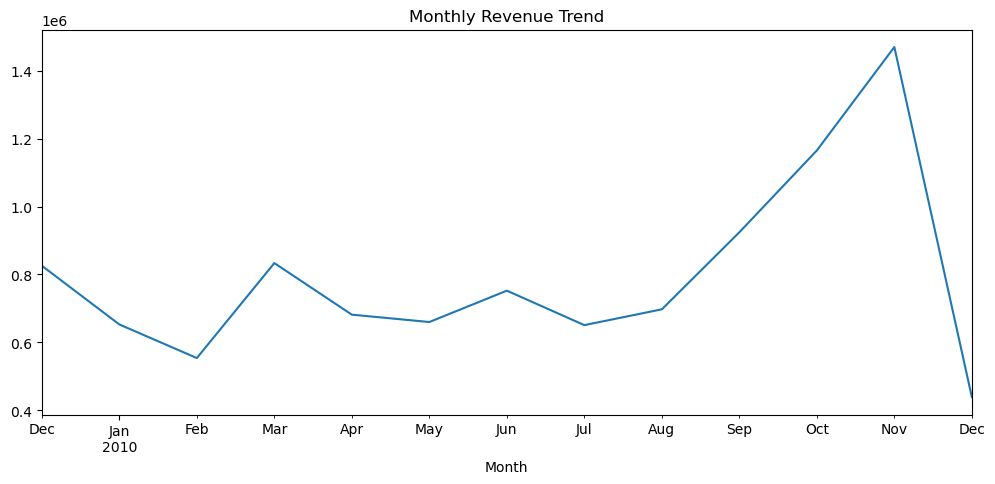

In [28]:
import matplotlib.pyplot as plt

monthly_sales.plot(figsize=(12,5), title="Monthly Revenue Trend")
plt.show()


In [20]:
top_customers = df_clean.groupby("Customer ID")["TotalPrice"].sum().sort_values(ascending=False).head(10)
top_customers 

In [21]:
top_customers = (
    df.groupby('Customer ID')['TotalPrice']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_customers


Customer ID
18102.0    341776.73
14646.0    243853.05
14156.0    183180.55
14911.0    137675.91
13694.0    128172.42
17511.0     83760.60
15061.0     82162.74
16684.0     75610.17
13089.0     55828.31
16754.0     54558.18
Name: TotalPrice, dtype: float64

<Axes: title={'center': 'Top 10 Customers by Total Spending'}, ylabel='Customer ID'>

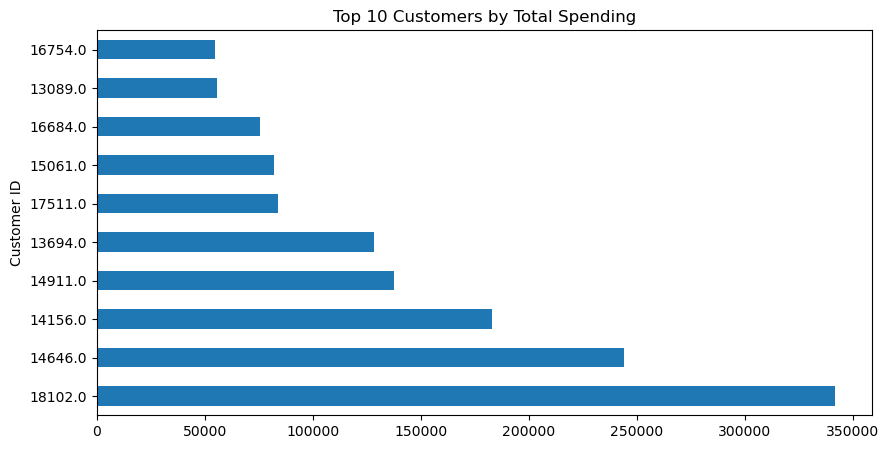

In [22]:
top_customers.plot(kind='barh', figsize=(10,5), title='Top 10 Customers by Total Spending')


In [23]:
#Veri seti, az sayıdaki müşterinin toplam gelirin orantısız derecede
#büyük bir kısmını oluşturduğunu göstermektedir.
#Bu durum, gelirde yüksek müşteri yoğunlaşmasına işaret etmektedir.

In [24]:
top_countries = (
    df.groupby('Country')['TotalPrice']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_countries
#Gelirin büyük bölümü Birleşik Krallık’tan elde edilmektedir.
#Bu durum, satışların coğrafi olarak tek bir pazarda yoğunlaştığını göstermektedir.

Country
United Kingdom    8194777.533
EIRE               352242.730
Netherlands        263863.410
Germany            196290.351
France             130769.900
Sweden              51213.510
Denmark             46972.950
Switzerland         43343.410
Spain               37084.900
Australia           30051.800
Name: TotalPrice, dtype: float64

<Axes: title={'center': 'Top 10 Countries by Revenue'}, xlabel='Country'>

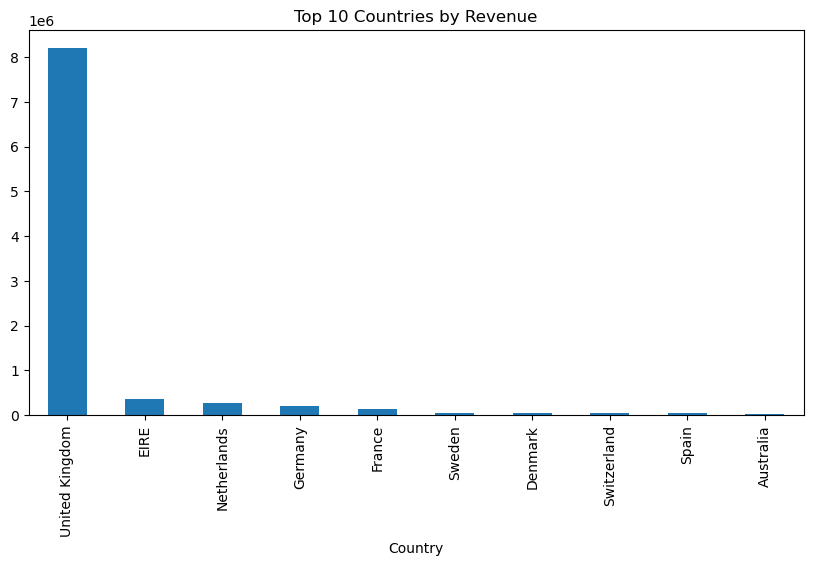

In [25]:
top_countries.plot(kind='bar', figsize=(10,5), title='Top 10 Countries by Revenue')


In [30]:
country_revenue = (
    df_clean.groupby("Country")["TotalPrice"]
            .sum()
            .sort_values(ascending=False)
)

country_revenue.head(10)


Country
United Kingdom    8846129.263
EIRE               380977.820
Netherlands        268786.000
Germany            202395.321
France             147211.490
Sweden              53525.390
Denmark             50906.850
Spain               47601.420
Switzerland         43921.390
Australia           31446.800
Name: TotalPrice, dtype: float64

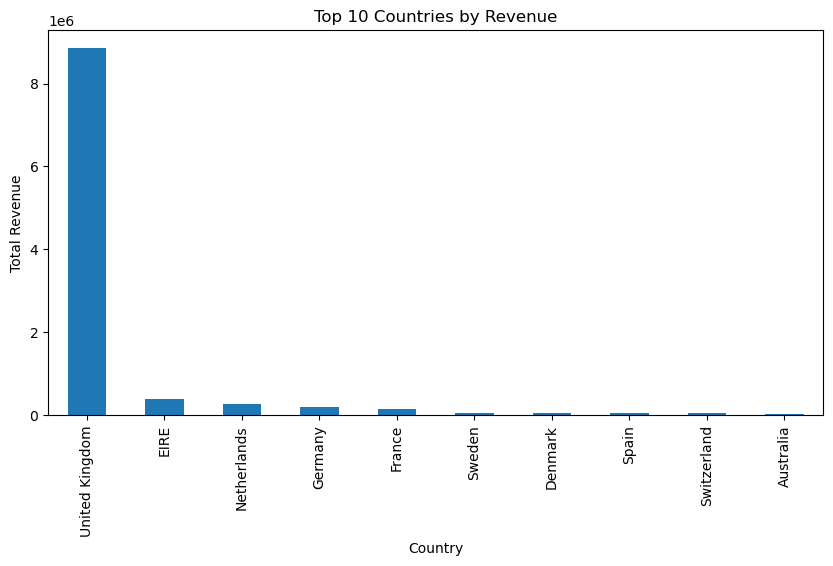

In [31]:
top_countries = country_revenue.head(10)

top_countries.plot(kind="bar", figsize=(10,5), title="Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Total Revenue")
plt.show()



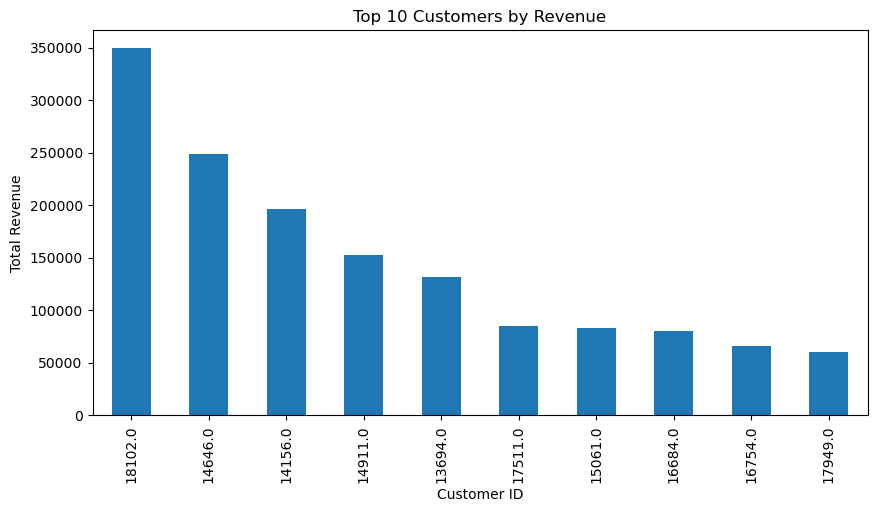

In [32]:
top_customers = (
    df_clean.groupby("Customer ID")["TotalPrice"]
            .sum()
            .sort_values(ascending=False)
            .head(10)
)

top_customers.plot(kind="bar", figsize=(10,5), title="Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Total Revenue")
plt.show()


### Insight: Top Customers by Revenue

A small group of customers accounts for a significant portion of total revenue. This indicates high revenue concentration and highlights the importance of retaining high-value customers.


## Key Insights

- The dataset contains over 525,000 transactions, making it suitable for large-scale analysis.
- Revenue is heavily concentrated among a small number of high-value customers.
- The United Kingdom generates the majority of total revenue, indicating geographic dependency.
- Monthly revenue trends show seasonal variation and year-end growth.
- Product sales are concentrated among a limited number of best-selling items.


## Technical Summary

This project applied structured data cleaning, feature engineering, aggregation, and visualization on a large retail dataset. Key transformations included handling missing values, removing invalid transactions, creating revenue-based features, and generating analytical summary tables.

The workflow demonstrates scalable data analysis practices suitable for analytics and data engineering pipelines.


## Final Project Summary

This Exploratory Data Analysis (EDA) project analyzed customer behavior, revenue patterns, and product performance in an online retail dataset. The project highlights key revenue drivers, customer concentration, and market dependency.

The results provide actionable insights for customer retention, market expansion, and sales optimization. This project demonstrates strong analytical thinking, data processing, and insight generation skills relevant to Data Engineering and Analytics roles.


---
**Project completed — Online Retail EDA Portfolio Project**  
Focus: Large-scale data analysis, transformation, and insight extraction
